# Code Generation Analysis

Analysis of code generation experiments across 3 agent designs (SA, DA, MA),
4 models (Qwen3-4B, Qwen3-30B, Nemotron-Nano-8B, Nemotron-Super-49B),
2 modes (instruct, thinking), and 2 prompting strategies (zero-shot, few-shot).

**Dataset**: HumanEval (164 problems), **Metric**: Pass@1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

BASE_DIR = Path('..').resolve()
RESULTS_DIR = BASE_DIR / 'results'
OUTPUT_DIR = BASE_DIR / 'notebooks' / 'results'
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load Data

In [2]:
# Load consolidated performance and emissions
perf_df = pd.read_csv(RESULTS_DIR / 'consolidated_performance.csv')
emissions_df = pd.read_csv(RESULTS_DIR / 'consolidated_emissions.csv')

# Filter to code generation
df = perf_df[perf_df['task'] == 'code_generation'].copy()

# Add percentage columns
df['pass_at_1_pct'] = df['pass_at_1'] * 100
df['pass_rate'] = df['passed_samples'] / df['total_samples'] * 100

# Merge emissions
emit_cols = ['model', 'parameters_b', 'design', 'task', 'dataset', 'mode', 'prompting',
             'total_energy_kwh', 'total_emissions_kg', 'total_duration_s', 'duration_hours']
df = pd.merge(df, emissions_df[emit_cols],
              on=['model', 'parameters_b', 'design', 'task', 'dataset', 'mode', 'prompting'],
              how='left')

# Short model labels
model_label = {
    'Qwen3-4B-Instruct': '4B Inst', 'Qwen3-4B-Thinking': '4B Think',
    'Qwen3-30B-A3B-Instruct': '30B Inst', 'Qwen3-30B-A3B-Thinking': '30B Think',
    'Nemotron-Nano-8B': '8B', 'Nemotron-Super-49B': '49B',
}
df['model_short'] = df['model'].map(model_label)

print(f'Experiments: {len(df)}')
print(f'\nBy design: {df["design"].value_counts().to_dict()}')
print(f'By model family: {df["model_family"].value_counts().to_dict()}')
print(f'By mode: {df["mode"].value_counts().to_dict()}')

Experiments: 48

By design: {'DA': 16, 'MA': 16, 'SA': 16}
By model family: {'Qwen': 24, 'Nemotron': 24}
By mode: {'instruct': 24, 'thinking': 24}


## 2. Color Configuration

In [3]:
# No NoAgent for code generation
DESIGN_COLORS = {'SA': '#2ecc71', 'DA': '#3498db', 'MA': '#e74c3c'}
DESIGN_ORDER = ['SA', 'DA', 'MA']
MODEL_COLORS = {4: '#3498db', 8: '#00bcd4', 30: '#9b59b6', 49: '#e91e63'}
MODE_COLORS = {'instruct': '#3498db', 'thinking': '#e74c3c'}
PROMPT_COLORS = {'zero-shot': '#95a5a6', 'few-shot': '#2c3e50'}

## 3. Overview: Pass@1 by Design

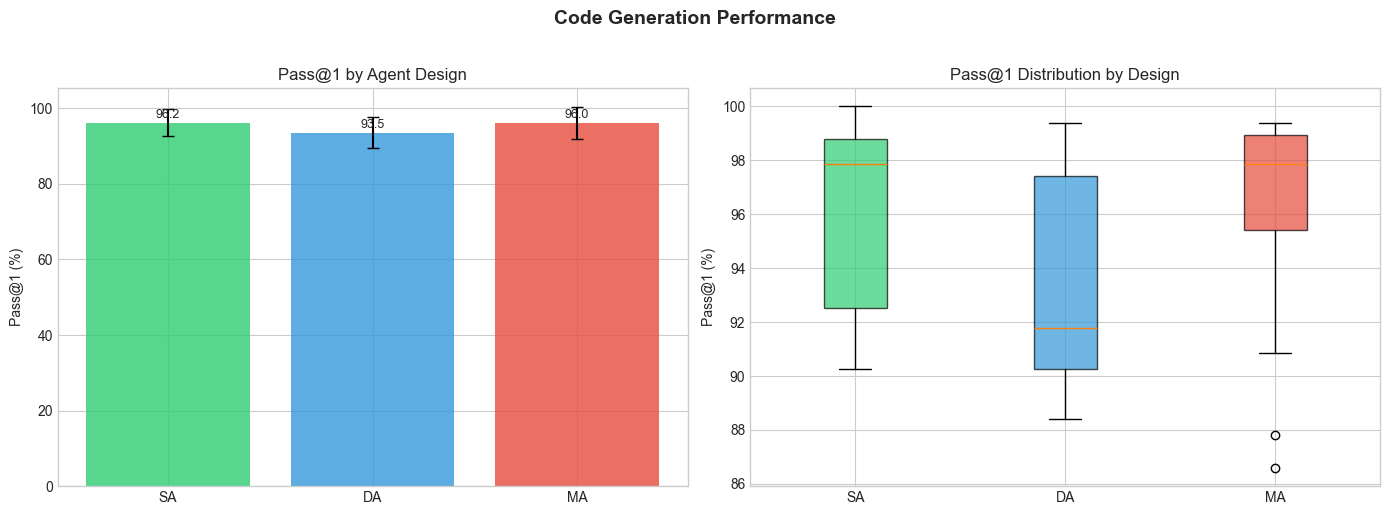

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pass@1 by design
ax = axes[0]
means = df.groupby('design')['pass_at_1_pct'].mean().reindex(DESIGN_ORDER)
stds = df.groupby('design')['pass_at_1_pct'].std().reindex(DESIGN_ORDER)
bars = ax.bar(range(len(DESIGN_ORDER)), means, yerr=stds, capsize=4,
              color=[DESIGN_COLORS[d] for d in DESIGN_ORDER], alpha=0.8)
ax.set_xticks(range(len(DESIGN_ORDER)))
ax.set_xticklabels(DESIGN_ORDER)
ax.set_ylabel('Pass@1 (%)')
ax.set_title('Pass@1 by Agent Design')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}',
            ha='center', va='bottom', fontsize=9)

# Boxplot
ax = axes[1]
design_data = [df[df['design'] == d]['pass_at_1_pct'].dropna() for d in DESIGN_ORDER]
bp = ax.boxplot(design_data, patch_artist=True, labels=DESIGN_ORDER)
for patch, design in zip(bp['boxes'], DESIGN_ORDER):
    patch.set_facecolor(DESIGN_COLORS[design])
    patch.set_alpha(0.7)
ax.set_ylabel('Pass@1 (%)')
ax.set_title('Pass@1 Distribution by Design')

fig.suptitle('Code Generation Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'codegen_design_comparison.png', bbox_inches='tight')
plt.show()

In [5]:
# Summary table
design_summary = df.groupby('design')['pass_at_1_pct'].agg(['mean', 'std', 'min', 'max']).round(2)
design_summary = design_summary.reindex(DESIGN_ORDER)
print('Pass@1 by Design:')
print(design_summary.to_string())

Pass@1 by Design:
         mean   std    min     max
design                            
SA      96.19  3.52  90.24  100.00
DA      93.49  4.10  88.41   99.39
MA      96.04  4.22  86.59   99.39


## 4. Model Size Scaling

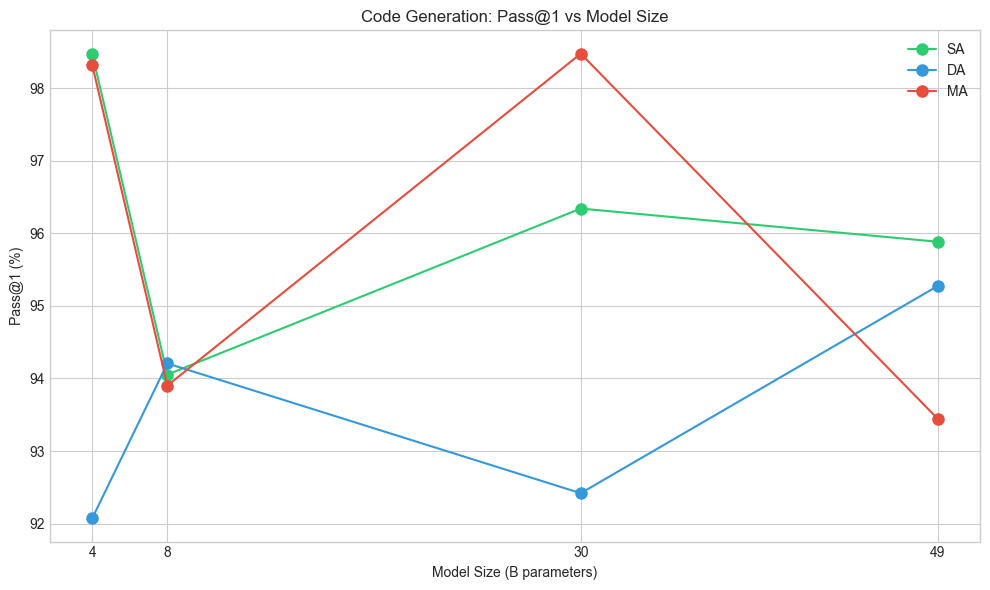

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for design in DESIGN_ORDER:
    sub = df[df['design'] == design].groupby('parameters_b')['pass_at_1_pct'].mean()
    ax.plot(sub.index, sub.values, 'o-', label=design, color=DESIGN_COLORS[design], markersize=8)

ax.set_xlabel('Model Size (B parameters)')
ax.set_ylabel('Pass@1 (%)')
ax.set_title('Code Generation: Pass@1 vs Model Size')
ax.legend()
ax.set_xticks([4, 8, 30, 49])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'codegen_model_size_scaling.png', bbox_inches='tight')
plt.show()

## 5. Mode and Prompting Effects

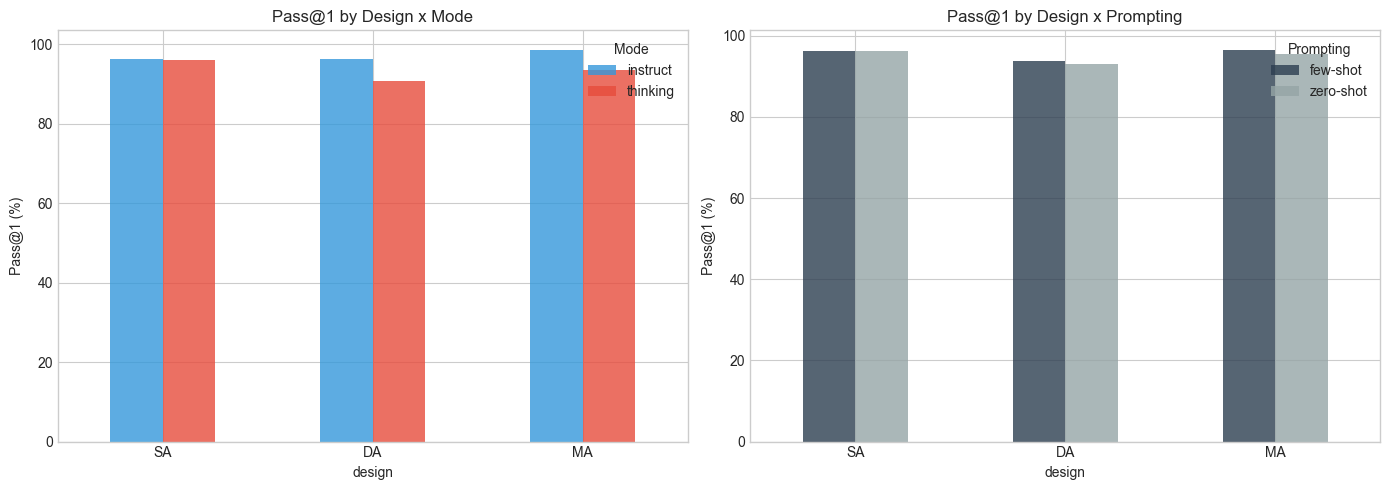

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mode effect
ax = axes[0]
mode_design = df.groupby(['design', 'mode'])['pass_at_1_pct'].mean().unstack()
mode_design = mode_design.reindex(DESIGN_ORDER)
mode_design.plot(kind='bar', ax=ax, color=[MODE_COLORS.get(c, '#999') for c in mode_design.columns], alpha=0.8)
ax.set_ylabel('Pass@1 (%)')
ax.set_title('Pass@1 by Design x Mode')
ax.set_xticklabels(DESIGN_ORDER, rotation=0)
ax.legend(title='Mode')

# Prompting effect
ax = axes[1]
prompt_design = df.groupby(['design', 'prompting'])['pass_at_1_pct'].mean().unstack()
prompt_design = prompt_design.reindex(DESIGN_ORDER)
prompt_design.plot(kind='bar', ax=ax, color=[PROMPT_COLORS.get(c, '#999') for c in prompt_design.columns], alpha=0.8)
ax.set_ylabel('Pass@1 (%)')
ax.set_title('Pass@1 by Design x Prompting')
ax.set_xticklabels(DESIGN_ORDER, rotation=0)
ax.legend(title='Prompting')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'codegen_mode_prompting.png', bbox_inches='tight')
plt.show()

## 6. Full Experiment Heatmap

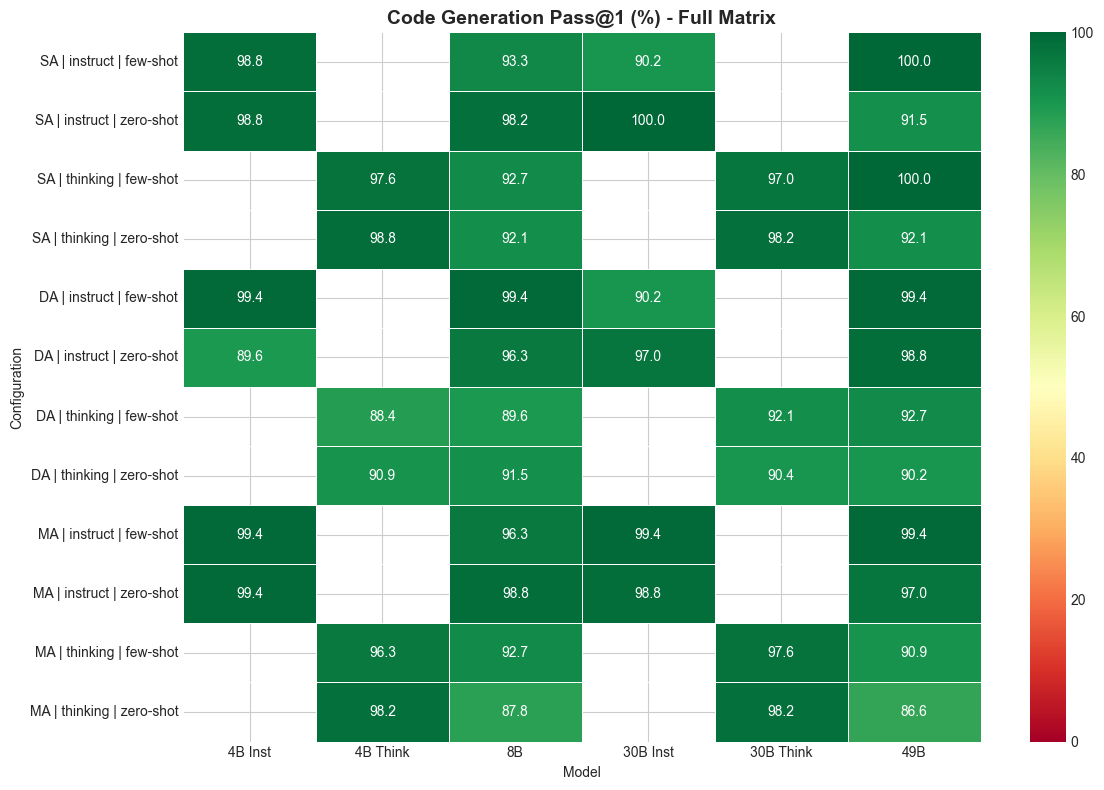

In [8]:
df['config'] = df['design'] + ' | ' + df['mode'] + ' | ' + df['prompting']

heatmap_data = df.pivot_table(values='pass_at_1_pct', index='config', columns='model_short',
                              aggfunc='mean')

design_sort = {d: i for i, d in enumerate(DESIGN_ORDER)}
heatmap_data['_sort'] = heatmap_data.index.map(lambda x: design_sort.get(x.split(' | ')[0], 99))
heatmap_data = heatmap_data.sort_values('_sort').drop(columns='_sort')

col_order = ['4B Inst', '4B Think', '8B', '30B Inst', '30B Think', '49B']
heatmap_data = heatmap_data[[c for c in col_order if c in heatmap_data.columns]]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=0.5, ax=ax, vmin=0, vmax=100)
ax.set_title('Code Generation Pass@1 (%) - Full Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Configuration')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'codegen_pass1_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Energy Efficiency

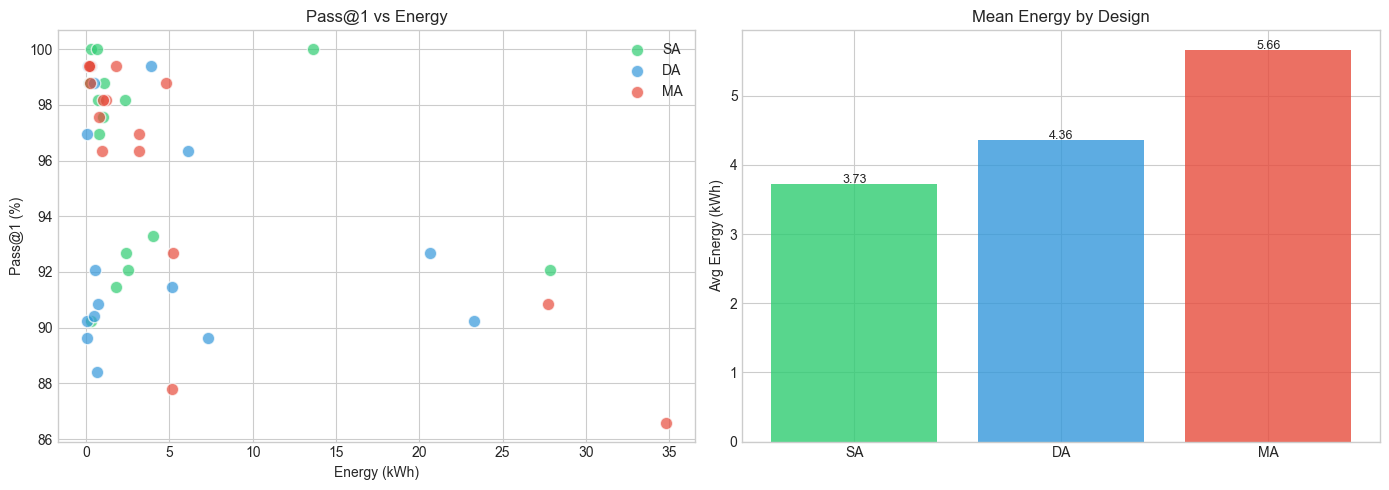

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pass@1 vs Energy
ax = axes[0]
for design in DESIGN_ORDER:
    sub = df[df['design'] == design]
    ax.scatter(sub['total_energy_kwh'], sub['pass_at_1_pct'],
               c=DESIGN_COLORS[design], label=design, s=80, alpha=0.7, edgecolors='white')
ax.set_xlabel('Energy (kWh)')
ax.set_ylabel('Pass@1 (%)')
ax.set_title('Pass@1 vs Energy')
ax.legend()

# Energy by design
ax = axes[1]
energy_means = df.groupby('design')['total_energy_kwh'].mean().reindex(DESIGN_ORDER)
ax.bar(range(len(DESIGN_ORDER)), energy_means,
       color=[DESIGN_COLORS[d] for d in DESIGN_ORDER], alpha=0.8)
ax.set_xticks(range(len(DESIGN_ORDER)))
ax.set_xticklabels(DESIGN_ORDER)
ax.set_ylabel('Avg Energy (kWh)')
ax.set_title('Mean Energy by Design')
for i, v in enumerate(energy_means):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'codegen_energy_analysis.png', bbox_inches='tight')
plt.show()

## 8. Best Configurations

In [10]:
print('Best Pass@1 per design:')
for design in DESIGN_ORDER:
    sub = df[df['design'] == design]
    best = sub.loc[sub['pass_at_1_pct'].idxmax()]
    print(f'  {design:4s}: Pass@1={best["pass_at_1_pct"]:.1f}%  '
          f'{best["model"]}  {best["mode"]}  {best["prompting"]}  ({best["total_energy_kwh"]:.2f} kWh)')

print('\nTop 10 configurations:')
top10 = df.nlargest(10, 'pass_at_1_pct')[['design', 'model', 'mode', 'prompting', 'pass_at_1_pct', 'total_energy_kwh']]
print(top10.to_string(index=False))

Best Pass@1 per design:
  SA  : Pass@1=100.0%  Qwen3-30B-A3B-Instruct  instruct  zero-shot  (0.32 kWh)
  DA  : Pass@1=99.4%  Qwen3-4B-Instruct  instruct  few-shot  (0.11 kWh)
  MA  : Pass@1=99.4%  Qwen3-4B-Instruct  instruct  few-shot  (0.21 kWh)

Top 10 configurations:
design                  model     mode prompting  pass_at_1_pct  total_energy_kwh
    SA Qwen3-30B-A3B-Instruct instruct zero-shot     100.000000          0.317469
    SA     Nemotron-Super-49B instruct  few-shot     100.000000          0.677730
    SA     Nemotron-Super-49B thinking  few-shot     100.000000         13.601003
    DA      Qwen3-4B-Instruct instruct  few-shot      99.390244          0.107970
    MA      Qwen3-4B-Instruct instruct  few-shot      99.390244          0.212963
    MA      Qwen3-4B-Instruct instruct zero-shot      99.390244          0.230137
    DA       Nemotron-Nano-8B instruct  few-shot      99.390244          3.875855
    MA Qwen3-30B-A3B-Instruct instruct  few-shot      99.390244          

## 9. Export

In [11]:
export_cols = ['design', 'model', 'model_family', 'parameters_b', 'mode', 'prompting',
               'pass_at_1_pct', 'passed_samples', 'failed_samples', 'total_samples',
               'total_energy_kwh', 'duration_hours']
df[export_cols].sort_values(['design', 'model', 'mode', 'prompting']).to_csv(
    OUTPUT_DIR / 'code_generation_analysis.csv', index=False)

summary = df.groupby(['design', 'mode', 'prompting']).agg({
    'pass_at_1_pct': 'mean', 'total_energy_kwh': 'mean'
}).round(2)
summary.to_csv(OUTPUT_DIR / 'code_generation_summary.csv')
print(f'Saved to {OUTPUT_DIR}')
print(summary.to_string())

Saved to /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/notebooks/results
                           pass_at_1_pct  total_energy_kwh
design mode     prompting                                 
DA     instruct few-shot           97.10              1.08
                zero-shot          95.43              1.68
       thinking few-shot           90.70              7.29
                zero-shot          90.74              7.40
MA     instruct few-shot           98.63              1.34
                zero-shot          98.48              2.11
       thinking few-shot           94.36              8.66
                zero-shot          92.68             10.53
SA     instruct few-shot           95.58              1.29
                zero-shot          97.10              1.16
       thinking few-shot           96.80              4.44
                zero-shot          95.27              8.03
